In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df6 = pd.read_csv('Dataset.csv')

In [ ]:
df6

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
...,...,...,...,...,...,...,...,...,...,...
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,Not Given,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Not Given,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV


In [ ]:
df6.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [ ]:
df6.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [ ]:
df6.describe()


,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
df6.count()

,0
show_id,8790
type,8790
title,8790
director,8790
country,8790
date_added,8790
release_year,8790
rating,8790
duration,8790
listed_in,8790


In [ ]:
df6.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [ ]:
df6['date_added'] = pd.to_datetime(df6['date_added'], errors='coerce')
df6 = df6.dropna(subset=['date_added'])

In [ ]:
df6.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [ ]:
# Engineered features
df6['year_added'] = df6['date_added'].dt.year
df6['content_age'] = df6['year_added'] - df6['release_year']  # how long after release it was added
df6['num_genres'] = df6['listed_in'].apply(lambda x: len(x.split(',')))
df6['is_multi_country'] = df6['country'].apply(lambda x: 1 if ',' in x else 0)
df6['primary_country'] = df6['country'].apply(lambda x: x.split(',')[0].strip())

# A simple proxy "success" label since we don't have real ratings/views data:
# treat titles with many genres + multi-country distribution as broader/higher-reach content
df6['broad_reach'] = ((df6['num_genres'] >= 3) | (df6['is_multi_country'] == 1)).astype(int)

print(df6[['title', 'content_age', 'num_genres', 'is_multi_country', 'primary_country', 'broad_reach']].head())
print("\nBroad reach distribution:\n", df6['broad_reach'].value_counts())

                              title  content_age  num_genres  \
0              Dick Johnson Is Dead            1           1   
1                         Ganglands            0           3   
2                     Midnight Mass            0           3   
3  Confessions of an Invisible Girl            0           2   
4                           Sankofa           28           3   

   is_multi_country primary_country  broad_reach  
0                 0   United States            0  
1                 0          France            1  
2                 0   United States            1  
3                 0          Brazil            0  
4                 0   United States            1  

Broad reach distribution:
 broad_reach
0    5064
1    3726
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Prepare features
features6 = df6[['type', 'rating', 'release_year', 'content_age', 'primary_country']].copy()
target6 = df6['broad_reach']

encoders6 = {}
for col in ['type', 'rating', 'primary_country']:
    le = LabelEncoder()
    features6[col] = le.fit_transform(features6[col])
    encoders6[col] = le

X_train6, X_test6, y_train6, y_test6 = train_test_split(
    features6, target6, test_size=0.2, random_state=42
)

# Train multiple models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train6, y_train6)
    trained_models[name] = model
    print(f"{name} trained.")

Logistic Regression trained.
Decision Tree trained.
Random Forest trained.
Gradient Boosting trained.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results6 = []
for name, model in trained_models.items():
    preds = model.predict(X_test6)
    results6.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test6, preds),
        'Precision': precision_score(y_test6, preds),
        'Recall': recall_score(y_test6, preds),
        'F1 Score': f1_score(y_test6, preds)
    })

results_df = pd.DataFrame(results6).sort_values('F1 Score', ascending=False)
print(results_df)

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f"\nBest model: {best_model_name}")

                 Model  Accuracy  Precision    Recall  F1 Score
3    Gradient Boosting  0.720137   0.662500  0.657025  0.659751
2        Random Forest  0.699659   0.649096  0.593664  0.620144
1        Decision Tree  0.683732   0.636656  0.545455  0.587537
0  Logistic Regression  0.620592   0.555347  0.407713  0.470214

Best model: Gradient Boosting


In [ ]:
from sklearn.model_selection import GridSearchCV

# Example: tuning Random Forest (swap params if your best model was Gradient Boosting instead)
if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    }
    base_model = RandomForestClassifier(random_state=42)

elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    }
    base_model = GradientBoostingClassifier(random_state=42)

else:
    param_grid = {'C': [0.1, 1, 10]}
    base_model = LogisticRegression(max_iter=1000)

grid_search6 = GridSearchCV(base_model, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search6.fit(X_train6, y_train6)

print("Best parameters:", grid_search6.best_params_)
print("Best CV F1 score:", round(grid_search6.best_score_, 3))

tuned_model = grid_search6.best_estimator_
tuned_preds = tuned_model.predict(X_test6)

print("\nTuned model test accuracy:", round(accuracy_score(y_test6, tuned_preds), 3))
print("Tuned model test F1:", round(f1_score(y_test6, tuned_preds), 3))

Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best CV F1 score: 0.689

Tuned model test accuracy: 0.72
Tuned model test F1: 0.657


In [ ]:
# Feature importance from the tuned model (works for tree-based models)
if hasattr(tuned_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': features6.columns,
        'importance': tuned_model.feature_importances_
    }).sort_values('importance', ascending=False)
    print("Feature Importance:\n", importance_df)
else:
    importance_df = None

# Automated insight generation
insights = []

# Insight 1: Top predictive feature
if importance_df is not None:
    top_feature = importance_df.iloc[0]['feature']
    insights.append(f"'{top_feature}' is the strongest predictor of broad-reach content.")

# Insight 2: Content type trend
type_reach = df6.groupby('type')['broad_reach'].mean().sort_values(ascending=False)
insights.append(f"'{type_reach.index[0]}' titles are more likely to have broad reach ({type_reach.iloc[0]:.1%}) than '{type_reach.index[1]}' ({type_reach.iloc[1]:.1%}).")

# Insight 3: Country trend
country_reach = df6.groupby('primary_country')['broad_reach'].mean()
country_counts = df6['primary_country'].value_counts()
top_countries = country_counts[country_counts > 50].index  # filter for countries with enough data
top_country_reach = country_reach[top_countries].sort_values(ascending=False)
insights.append(f"Content primarily from '{top_country_reach.index[0]}' shows the highest broad-reach rate ({top_country_reach.iloc[0]:.1%}) among major content-producing countries.")

# Insight 4: Recency trend
recent_reach = df6[df6['release_year'] >= 2018]['broad_reach'].mean()
older_reach = df6[df6['release_year'] < 2018]['broad_reach'].mean()
insights.append(f"Titles released 2018 or later have a {recent_reach:.1%} broad-reach rate vs {older_reach:.1%} for older titles.")

print("\n--- AUTOMATED INSIGHTS ---")
for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

Feature Importance:
            feature  importance
4  primary_country    0.618054
1           rating    0.213995
0             type    0.093471
3      content_age    0.054791
2     release_year    0.019689

--- AUTOMATED INSIGHTS ---
1. 'primary_country' is the strongest predictor of broad-reach content.
2. 'TV Show' titles are more likely to have broad reach (49.4%) than 'Movie' (39.3%).
3. Content primarily from 'South Korea' shows the highest broad-reach rate (83.2%) among major content-producing countries.
4. Titles released 2018 or later have a 42.9% broad-reach rate vs 42.0% for older titles.


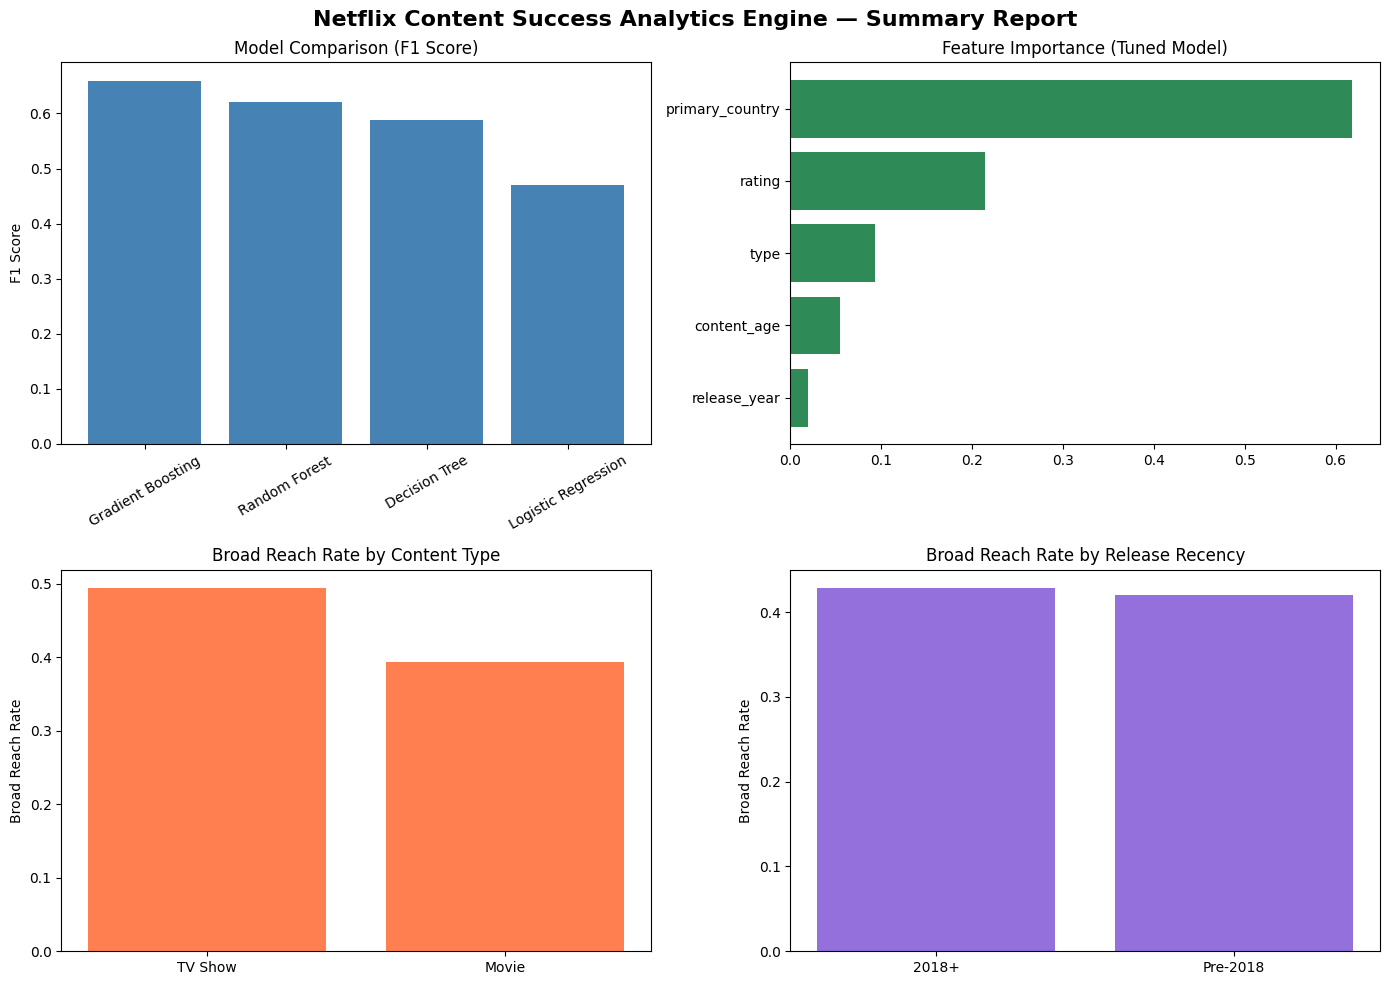


Report saved as 'netflix_analytics_report.png'

=== FINAL SUMMARY ===
Best Model: Gradient Boosting (tuned)
Test Accuracy: 72.0%
Test F1 Score: 0.657

Key Insights:
1. 'primary_country' is the strongest predictor of broad-reach content.
2. 'TV Show' titles are more likely to have broad reach (49.4%) than 'Movie' (39.3%).
3. Content primarily from 'South Korea' shows the highest broad-reach rate (83.2%) among major content-producing countries.
4. Titles released 2018 or later have a 42.9% broad-reach rate vs 42.0% for older titles.


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Netflix Content Success Analytics Engine — Summary Report', fontsize=16, fontweight='bold')

# 1. Model comparison
axes[0,0].bar(results_df['Model'], results_df['F1 Score'], color='steelblue')
axes[0,0].set_title('Model Comparison (F1 Score)')
axes[0,0].set_ylabel('F1 Score')
axes[0,0].tick_params(axis='x', rotation=30)

# 2. Feature importance
if importance_df is not None:
    axes[0,1].barh(importance_df['feature'], importance_df['importance'], color='seagreen')
    axes[0,1].set_title('Feature Importance (Tuned Model)')
    axes[0,1].invert_yaxis()

# 3. Broad reach by content type
axes[1,0].bar(type_reach.index, type_reach.values, color='coral')
axes[1,0].set_title('Broad Reach Rate by Content Type')
axes[1,0].set_ylabel('Broad Reach Rate')

# 4. Broad reach by release recency
axes[1,1].bar(['2018+', 'Pre-2018'], [recent_reach, older_reach], color='mediumpurple')
axes[1,1].set_title('Broad Reach Rate by Release Recency')
axes[1,1].set_ylabel('Broad Reach Rate')

plt.tight_layout()
plt.savefig('netflix_analytics_report.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nReport saved as 'netflix_analytics_report.png'")
print("\n=== FINAL SUMMARY ===")
print(f"Best Model: {best_model_name} (tuned)")
print(f"Test Accuracy: {accuracy_score(y_test6, tuned_preds):.1%}")
print(f"Test F1 Score: {f1_score(y_test6, tuned_preds):.3f}")
print("\nKey Insights:")
for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")